# 03 · Triple Barrier Labeling

## 0 · Setup

In [1]:
import sys, logging
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)-8s | %(name)s | %(message)s'
)
log = logging.getLogger('labeling')

from src.utils.io     import save, load
from src.config import load_config

cfg = load_config(ROOT / 'configs' / 'base.yaml')

print(f'ROOT       : {ROOT}')
print(f'horizon    = {cfg.labeling.horizon}')
print(f'pt_sl_mult = {cfg.labeling.pt_sl_mult}')
print(f'vol_window = {cfg.labeling.vol_window}')

ROOT       : C:\Users\H13P\Desktop\DOAN - Copy\project_v7_final - Copy\project_v7_final
horizon    = 10
pt_sl_mult = 1.5
vol_window = 20


## 1 · Load dataset từ bước Feature Engineering

In [2]:
featured = load(cfg.dir_processed / 'dataset_features.parquet')

print(f'Shape     : {featured.shape}')
print(f'Tickers   : {featured.index.get_level_values("ticker").nunique()}')
print(f'Date range: {featured.index.get_level_values("date").min().date()} → '
      f'{featured.index.get_level_values("date").max().date()}')
featured.head()

Shape     : (103000, 73)
Tickers   : 36
Date range: 2014-05-27 → 2026-02-27


adj_open   adj_high    adj_low  adj_close   adj_volume  \
date       ticker                                                            
2014-05-27 AAPL    19.307091  19.619952  19.299254  19.612742  348866348.0   
           ADBE    64.640000  65.485000  64.610000  65.250000    2150600.0   
           AMAT    17.421516  17.766838  17.222955  17.766838   20049000.0   
           AMD      4.050000   4.060000   4.030000   4.040000    6922800.0   
           AMGN    83.021844  83.158145  82.297295  83.136624    2513900.0   

                     vix    vxn  bench_close    ret_1d    ret_5d  ...  \
date       ticker                                                 ...   
2014-05-27 AAPL    11.51  13.72    83.058014  0.018553  0.034209  ...   
           ADBE    11.51  13.72    83.058014  0.014666  0.047871  ...   
           AMAT    11.51  13.72    83.058014  0.026589  0.027625  ...   
           AMD     11.51  13.72    83.058014  0.004963 -0.012300  ...   
           AMGN    11.51  13.72    83.058014  0.013552  0.033429  ...   

                   rolling_beta_63d  resid_ret_21d  idio_vol_21d  \
date       ticker                                                  
2014-05-27 AAPL            0.660530       0.059435      0.009340   
           ADBE            1.226117      -0.009183      0.009961   
           AMAT            1.112282       0.044701      0.018477   
           AMD             1.137850      -0.064263      0.013371   
           AMGN            1.290469      -0.025165      0.009119   

                   rel_strength_21d  rel_strength_63d  downside_beta_63d  \
date       ticker                                                          
2014-05-27 AAPL            0.041000          0.172519           0.357721   
           ADBE            0.003097         -0.055466           0.907632   
           AMAT            0.050798          0.069811           1.677914   
           AMD            -0.056777          0.076581           0.976221   
           AMGN           -0.009391         -0.079087           1.387936   

                   p_high_vol  p_high_x_mom_63d  p_high_x_vol_21d  \
date       ticker                                                   
2014-05-27 AAPL           0.5          0.093278          0.005540   
           ADBE           0.5         -0.020714          0.007379   
           AMAT           0.5          0.041924          0.010078   
           AMD            0.5          0.045309          0.008170   
           AMGN           0.5         -0.032525          0.004460   

                   p_high_x_resid_ret  
date       ticker                      
2014-05-27 AAPL              0.029717  
           ADBE             -0.004591  
           AMAT              0.022350  
           AMD              -0.032132  
           AMGN             -0.012582  

[5 rows x 73 columns]

## 2 · Triple Barrier Labeling (Chương 3.6)

**Triple Barrier** — López de Prado (2018):

| Barrier | Điều kiện | Label |
|---------|-----------|-------|
| **Upper (PT)** | return ≥ `pt_sl_mult × daily_vol` | 1 (tăng) |
| **Lower (SL)** | return ≤ `−pt_sl_mult × daily_vol` | 0 (giảm) |
| **Vertical (H)** | hết `horizon` ngày giao dịch | 1 nếu return > 0, else 0 |

Label **binary (0/1)** — phù hợp classification + ranking top-K.

In [3]:
# Import từ src/
from src.labeling import label as triple_barrier_label


In [4]:
featured = triple_barrier_label(
    featured,
    horizon=cfg.labeling.horizon,
    pt_sl_mult=cfg.labeling.pt_sl_mult,
    vol_window=cfg.labeling.vol_window,
)
print(f'Shape: {featured.shape}')
print(f'Labels: {featured["tb_label"].value_counts()}')

INFO     | src.labeling.triple_barrier | Triple Barrier: H=10, pt_sl_mult=1.5, vol_window=20
INFO     | src.labeling.triple_barrier |   Labels: 102,604 | 1=55,311 (53.9%) | 0=47,293 (46.1%)
INFO     | src.labeling.triple_barrier |   Barriers: {'PT': 52156, 'SL': 44949, 'VERT': 5499}


Shape: (103000, 79)
Labels: tb_label
1.0    55311
0.0    47293
Name: count, dtype: int64


## 3 · Kiểm tra labels

In [5]:
# 3.1 Drop rows không có label (cuối chuỗi thiếu horizon)
n_no_label = featured['tb_label'].isna().sum()
featured = featured.dropna(subset=['tb_label'])
print(f'Dropped {n_no_label:,} rows không có label (cuối chuỗi)')
print(f'Shape  : {featured.shape}')

Dropped 396 rows không có label (cuối chuỗi)
Shape  : (102604, 79)


In [6]:
# 3.2 Label distribution
valid = featured['tb_label']
n_pos = (valid == 1).sum()
n_neg = (valid == 0).sum()
print(f'Label 1 (tăng): {n_pos:,} ({n_pos/len(valid):.1%})')
print(f'Label 0 (giảm): {n_neg:,} ({n_neg/len(valid):.1%})')
print(f'\nBarrier distribution:')
print(featured['tb_barrier'].value_counts())

Label 1 (tăng): 55,311 (53.9%)
Label 0 (giảm): 47,293 (46.1%)

Barrier distribution:
tb_barrier
PT      52156
SL      44949
VERT     5499
Name: count, dtype: int64


In [7]:
# 3.3 Label theo năm
flat = featured.reset_index()
flat['year'] = flat['date'].dt.year

label_by_year = flat.groupby('year')['tb_label'].agg(['count', 'mean'])
label_by_year.columns = ['n_samples', 'pct_positive']
label_by_year['pct_positive'] = label_by_year['pct_positive'].apply(lambda x: f'{x:.1%}')
label_by_year

,n_samples,pct_positive
year,,
2014,4954,54.4%
2015,8808,50.0%
2016,9027,53.2%
2017,8616,59.7%
2018,8961,53.1%
2019,9004,57.4%
2020,7477,59.6%
2021,8506,54.4%
2022,9006,46.1%


In [8]:
# 3.4 Barrier theo năm
barrier_by_year = flat.groupby(['year', 'tb_barrier']).size().unstack(fill_value=0)
barrier_by_year['total'] = barrier_by_year.sum(axis=1)
for col in ['PT', 'SL', 'VERT']:
    if col in barrier_by_year.columns:
        barrier_by_year[f'{col}%'] = (barrier_by_year[col] / barrier_by_year['total']).apply(
            lambda x: f'{x:.0%}')
barrier_by_year

tb_barrier,PT,SL,VERT,total,PT%,SL%,VERT%
year,,,,,,,
2014,2520,2176,258,4954,51%,44%,5%
2015,4129,4194,485,8808,47%,48%,6%
2016,4448,3938,641,9027,49%,44%,7%
2017,4895,3249,472,8616,57%,38%,5%
2018,4539,4049,373,8961,51%,45%,4%
2019,4866,3620,518,9004,54%,40%,6%
2020,4057,2839,581,7477,54%,38%,8%
2021,4421,3740,345,8506,52%,44%,4%
2022,4013,4676,317,9006,45%,52%,4%


In [9]:
# 3.5 Holding period (trading days)
holding = featured['holding_td']

print(f'Holding period (trading days):')
print(f'  Mean   : {holding.mean():.1f}')
print(f'  Median : {holding.median():.1f}')
print(f'  Min    : {holding.min():.0f}')
print(f'  Max    : {holding.max():.0f}')

for barrier in ['PT', 'SL', 'VERT']:
    mask = featured['tb_barrier'] == barrier
    if mask.sum() > 0:
        h = holding[mask]
        print(f'  {barrier:4s} : mean={h.mean():.1f}td, median={h.median():.1f}td')

Holding period (trading days):
  Mean   : 3.4
  Median : 3.0
  Min    : 1
  Max    : 10
  PT   : mean=3.1td, median=2.0td
  SL   : mean=3.0td, median=2.0td
  VERT : mean=9.9td, median=10.0td


## 4 · Embargo mask (Chương 3.4.2)

Mỗi label tại `t` dùng data tới `t + H`.  
→ Khi chia train/test, `H` ngày đầu test bị **chồng lấn** với cuối train.  
→ **Embargo** = loại `H` ngày ngay sau `train_end`.

Hàm `embargo_mask()` sẽ dùng trong notebook 04 (walk-forward).

In [10]:
def embargo_mask(df, train_end, horizon=10):
    """
    Trả về index các mẫu trong vùng embargo.
    Embargo = H ngày giao dịch ngay SAU train_end.
    """
    train_end = pd.Timestamp(train_end)
    dates_all = df.index.get_level_values('date').unique().sort_values()
    future_dates = dates_all[dates_all > train_end]

    if len(future_dates) < horizon:
        embargo_dates = future_dates
    else:
        embargo_dates = future_dates[:horizon]

    mask = df.index.get_level_values('date').isin(embargo_dates)
    return df.index[mask]


# Demo
train_end_demo = '2022-12-30'
emb_idx = embargo_mask(featured, train_end=train_end_demo, horizon=cfg.labeling.horizon)
emb_dates = emb_idx.get_level_values('date').unique().sort_values()

print(f'Train end   : {train_end_demo}')
print(f'Embargo     : {len(emb_dates)} ngày, {len(emb_idx)} mẫu')
print(f'Embargo từ  : {emb_dates[0].date()} → {emb_dates[-1].date()}')
print(f'Test bắt đầu: sau {emb_dates[-1].date()}')

Train end   : 2022-12-30
Embargo     : 10 ngày, 359 mẫu
Embargo từ  : 2023-01-03 → 2023-01-17
Test bắt đầu: sau 2023-01-17


## 5 · Visualize

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

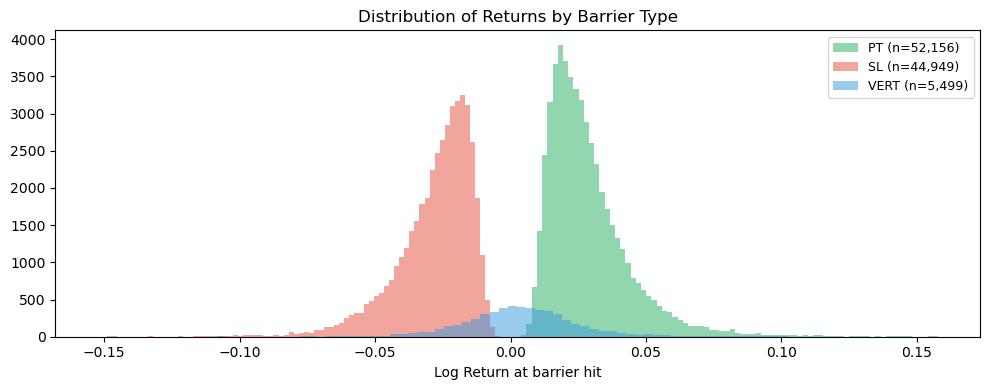

In [12]:
# 5.1 Return distribution by barrier
fig, ax = plt.subplots(figsize=(10, 4))
for barrier, color in [('PT', '#27ae60'), ('SL', '#e74c3c'), ('VERT', '#3498db')]:
    subset = featured.loc[featured['tb_barrier'] == barrier, 'tb_return'].dropna()
    ax.hist(subset, bins=80, alpha=0.5, color=color,
            label=f'{barrier} (n={len(subset):,})')
ax.set_title('Distribution of Returns by Barrier Type', fontsize=12)
ax.set_xlabel('Log Return at barrier hit')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

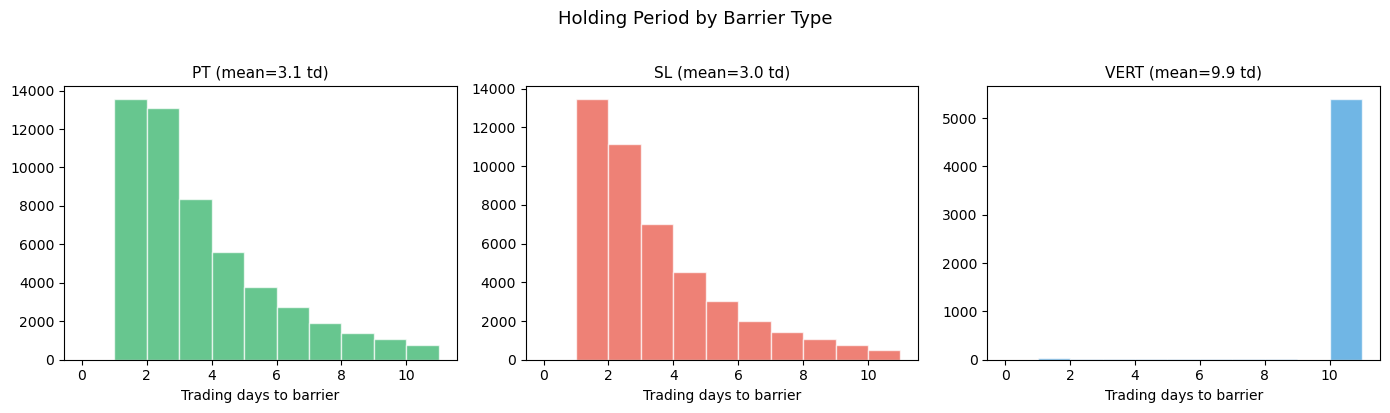

In [13]:
# 5.2 Holding period distribution (trading days)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, barrier, color in zip(axes, ['PT', 'SL', 'VERT'],
                               ['#27ae60', '#e74c3c', '#3498db']):
    mask = featured['tb_barrier'] == barrier
    h = holding[mask].dropna()
    ax.hist(h, bins=range(0, cfg.labeling.horizon + 2), color=color,
            alpha=0.7, edgecolor='white')
    ax.set_title(f'{barrier} (mean={h.mean():.1f} td)', fontsize=11)
    ax.set_xlabel('Trading days to barrier')
plt.suptitle('Holding Period by Barrier Type', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

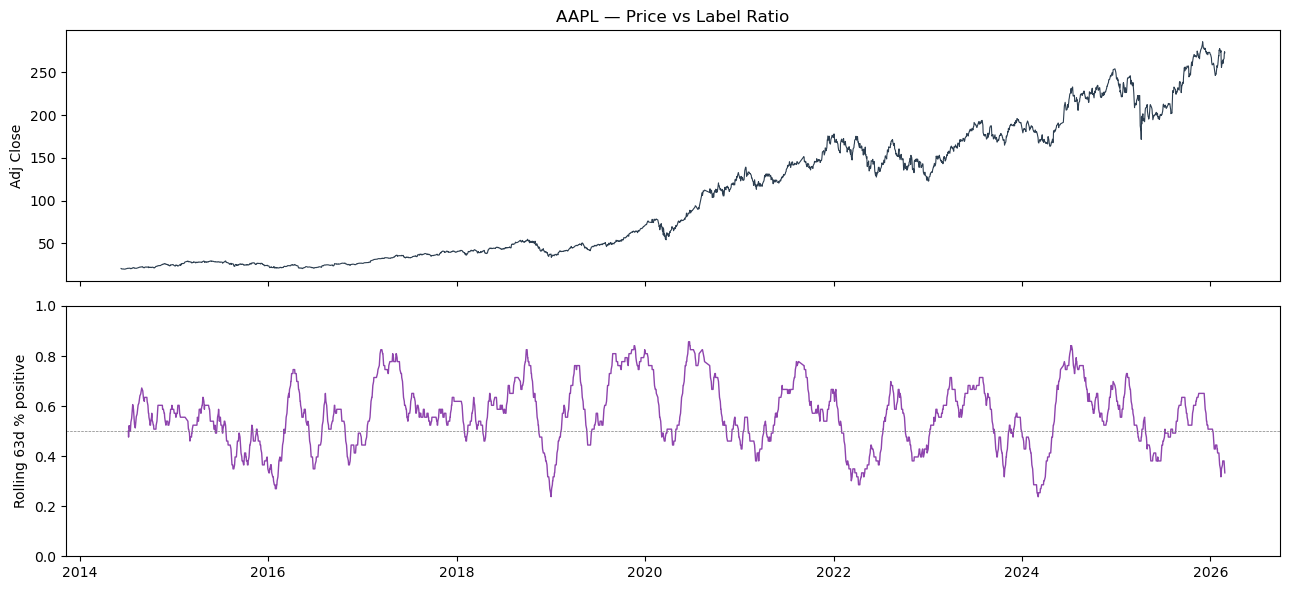

In [14]:
# 5.3 Label ratio qua thời gian (rolling 63 trading days)
sample_tkr = featured.index.get_level_values('ticker').unique()[0]
ts = featured.xs(sample_tkr, level='ticker')

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(ts.index, ts['adj_close'], lw=0.8, color='#2c3e50')
axes[0].set_ylabel('Adj Close')
axes[0].set_title(f'{sample_tkr} — Price vs Label Ratio', fontsize=12)

roll_pct = ts['tb_label'].rolling(63, min_periods=20).mean()
axes[1].plot(ts.index, roll_pct, lw=1, color='#8e44ad')
axes[1].axhline(0.5, color='gray', ls='--', lw=0.5)
axes[1].set_ylabel('Rolling 63d % positive')
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

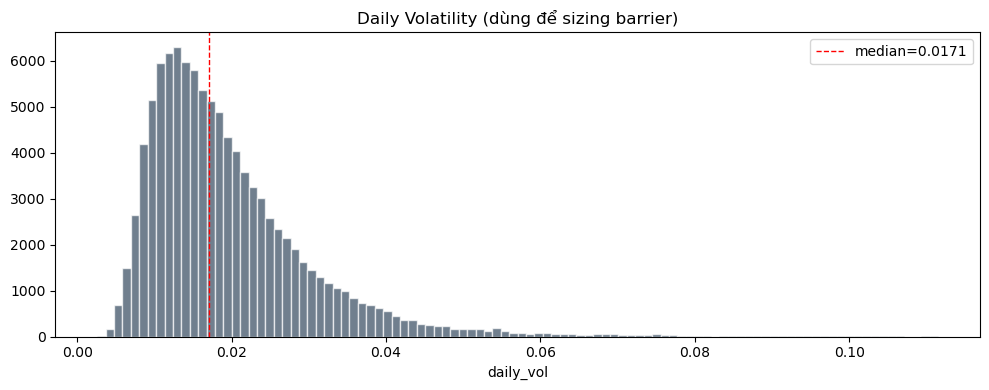

In [15]:
# 5.4 Daily vol distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(featured['daily_vol'].dropna(), bins=100, color='#34495e',
        alpha=0.7, edgecolor='white')
ax.set_title('Daily Volatility (dùng để sizing barrier)', fontsize=12)
ax.set_xlabel('daily_vol')
ax.axvline(featured['daily_vol'].median(), color='red', ls='--', lw=1,
           label=f'median={featured["daily_vol"].median():.4f}')
ax.legend()
plt.tight_layout()
plt.show()

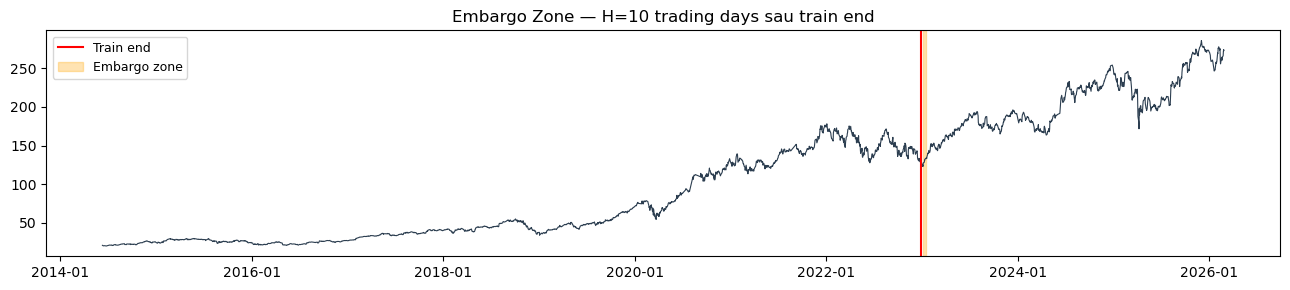

In [16]:
# 5.5 Embargo zone visualization
fig, ax = plt.subplots(figsize=(13, 3))
train_end_dt = pd.Timestamp(train_end_demo)

ts_price = featured.xs(sample_tkr, level='ticker')['adj_close']
ax.plot(ts_price.index, ts_price.values, lw=0.8, color='#2c3e50')

ax.axvline(train_end_dt, color='red', lw=1.5, label='Train end')
ax.axvspan(emb_dates[0], emb_dates[-1], alpha=0.3, color='orange', label='Embargo zone')
ax.set_title(f'Embargo Zone — H={cfg.labeling.horizon} trading days sau train end', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

## 6 · Sanity Checks

In [17]:
# Label hợp lệ
assert featured['tb_label'].isin([0, 1]).all(), 'Label không phải 0/1!'
print('✓ Label ∈ {0, 1}')

assert featured['tb_barrier'].isin(['PT', 'SL', 'VERT']).all(), 'Barrier lạ!'
print('✓ Barrier ∈ {PT, SL, VERT}')

assert featured['t1'].notna().all(), 't1 có NaT!'
print('✓ t1 không có NaT')

# t1 >= entry date (barrier không quay ngược)
entry_dates = featured.index.get_level_values('date')
assert (featured['t1'] >= entry_dates).all(), 't1 < entry date — future leak!'
print('✓ t1 >= entry date (no future leak)')

# Holding period ∈ [1, horizon] — đếm bằng TRADING days
assert (holding >= 1).all(), 'holding_td < 1!'
assert (holding <= cfg.labeling.horizon).all(), \
    f'holding_td > {cfg.labeling.horizon}! max={holding.max():.0f}'
print(f'✓ Holding period ∈ [1, {cfg.labeling.horizon}] trading days')

assert featured.index.names == ['date', 'ticker'], 'MultiIndex sai!'
assert not featured.index.duplicated().any(), 'Duplicate!'
print('✓ MultiIndex OK, no duplicates')

print(f'\n✓ All checks passed!')
print(f'  Shape   : {featured.shape}')
print(f'  Labels  : 1={n_pos:,} / 0={n_neg:,}')
print(f'  Tickers : {featured.index.get_level_values("ticker").nunique()}')

✓ Label ∈ {0, 1}
✓ Barrier ∈ {PT, SL, VERT}
✓ t1 không có NaT
✓ t1 >= entry date (no future leak)
✓ Holding period ∈ [1, 10] trading days
✓ MultiIndex OK, no duplicates

✓ All checks passed!
  Shape   : (102604, 79)
  Labels  : 1=55,311 / 0=47,293
  Tickers : 36


## 7 · Lưu Parquet
`data/processed/dataset_labeled.parquet` → input cho notebook 04 (modeling)

In [18]:
save(featured, cfg.dir_processed / 'dataset_labeled.parquet')

p = cfg.dir_processed / 'dataset_labeled.parquet'
size_kb = p.stat().st_size / 1024
print(f'{p.name:<40} {size_kb:>8.1f} KB')

dataset_labeled.parquet                   63301.8 KB


## 8 · Verify round-trip

In [19]:
reloaded = load(cfg.dir_processed / 'dataset_labeled.parquet')

assert reloaded.index.names == ['date', 'ticker']
assert len(reloaded) == len(featured)
assert 'tb_label' in reloaded.columns
assert 'tb_barrier' in reloaded.columns
assert 't1' in reloaded.columns
assert 'holding_td' in reloaded.columns
assert reloaded['tb_label'].isin([0, 1]).all()

print(f'✓ Round-trip OK: {reloaded.shape}')
reloaded[['adj_close', 'tb_label', 'tb_barrier', 'tb_return', 't1', 'holding_td', 'daily_vol']].head(10)

✓ Round-trip OK: (102604, 79)


adj_close  tb_label tb_barrier  tb_return         t1  \
date       ticker                                                         
2014-06-10 AAPL    20.682383       0.0         SL  -0.013672 2014-06-12   
           ADBE    66.960000       1.0         PT   0.017388 2014-06-18   
           AMAT    18.897769       1.0         PT   0.022788 2014-06-13   
           AMD      4.200000       1.0         PT   0.021898 2014-06-11   
           AMGN    84.004648       0.0         SL  -0.012942 2014-06-13   
           AMZN    16.620500       0.0         SL  -0.028852 2014-06-20   
           AVGO     5.431113       0.0         SL  -0.010590 2014-06-13   
           CDNS    17.050000       0.0         SL  -0.016266 2014-06-12   
           COST    93.770089       0.0         SL  -0.010890 2014-06-12   
           CRM     52.415381       1.0         PT   0.028927 2014-06-16   

                   holding_td  daily_vol  
date       ticker                         
2014-06-10 AAPL           2.0   0.009115  
           ADBE           6.0   0.011592  
           AMAT           3.0   0.015192  
           AMD            1.0   0.014599  
           AMGN           3.0   0.008628  
           AMZN           8.0   0.019235  
           AVGO           3.0   0.007060  
           CDNS           2.0   0.010844  
           COST           2.0   0.007260  
           CRM            4.0   0.019284